# Load Data

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
df_00 = pd.read_parquet('../../datasets/mimic_vitals_p00.parquet')
df_01 = pd.read_parquet('../../datasets/mimic_vitals_p01.parquet')
df_02 = pd.read_parquet('../../datasets/mimic_vitals_p02.parquet')
df_03 = pd.read_parquet('../../datasets/mimic_vitals_p03.parquet')
df_04 = pd.read_parquet('../../datasets/mimic_vitals_p04.parquet')
df_05 = pd.read_parquet('../../datasets/mimic_vitals_p05.parquet')
df_06 = pd.read_parquet('../../datasets/mimic_vitals_p06.parquet')
df_07 = pd.read_parquet('../../datasets/mimic_vitals_p07.parquet')
df_08 = pd.read_parquet('../../datasets/mimic_vitals_p08.parquet')
df_09 = pd.read_parquet('../../datasets/mimic_vitals_p09.parquet')

data = pd.concat([
    df_00, 
    df_01, 
    df_02, 
    df_03, 
    df_04, 
    df_05, 
    df_06, 
    df_07, 
    df_08, 
    df_09
])

In [44]:
filtered_data = data[['HR', 'RESP', 'SpO2', 'Minute', 'Record']]
# sorted_data = filtered_data.sort_values(by=['Record', 'Minute'])
# print(sorted_data.head())

In [45]:
print(filtered_data['Record'].nunique())

11105


In [46]:
#Drop first 30 minutes from each record
filtered_data = filtered_data[filtered_data["Minute"] >= 30].copy()

In [47]:
print(filtered_data.isna().sum())

HR        206920
RESP      328512
SpO2      838144
Minute         0
Record         0
dtype: int64


In [48]:
#Set 0's to NaN so they are filtered out
filtered_data[['HR', 'RESP', 'SpO2']] = filtered_data[['HR', 'RESP', 'SpO2']].replace(0, np.nan)

#Handle Missing Values
for col in ['HR', 'RESP', 'SpO2']:
    filtered_data[f"{col}_missing"] = filtered_data[col].isna().astype(int) #Add mask column
    # filtered_data[f"{col}_delta"] = filtered_data.groupby("Record")[f"{col}_missing"].cumsum() # add delta column
    filtered_data[f"{col}_delta"] = (
        filtered_data.groupby("Record")
        .apply(lambda g: (
            g["Minute"] - g["Minute"].where(g[col].notna()).ffill()
        ).fillna(0))
        .reset_index(level=0, drop=True)
    )

filtered_data[['HR', 'RESP', 'SpO2']] = filtered_data.groupby("Record")[['HR', 'RESP', 'SpO2']].ffill() #forward fill missing values within each record
filtered_data[['HR', 'RESP', 'SpO2']] = filtered_data[['HR', 'RESP', 'SpO2']].fillna(filtered_data[['HR', 'RESP', 'SpO2']].mean()) #fill any remaining missing values with column mean
# filtered_data[['HR', 'RESP', 'SpO2']] = filtered_data[['HR', 'RESP', 'SpO2']].fillna(0) #fill any remaining missing values with 0

#reset indices
filtered_data = filtered_data.reset_index(drop=True)

/tmp/ipykernel_4118029/2856099410.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (
/tmp/ipykernel_4118029/2856099410.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (
/tmp/ipykernel_4118029/2856099410.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping colu

In [49]:
test_ids = np.load('../../datasets/test_records.npy', allow_pickle=True)
train_ids = np.setdiff1d(filtered_data['Record'].unique(), test_ids)
train_df = filtered_data[filtered_data['Record'].isin(train_ids)].sort_values(by=['Record', 'Minute'])
test_df = filtered_data[filtered_data['Record'].isin(test_ids)].sort_values(by=['Record', 'Minute'])
print(f'Train df ({train_df.shape}): \n{train_df.head()}')
print(f'Test df ({test_df.shape}): \n{test_df.head()}')

Train df ((10665132, 11)): 
        HR  RESP  SpO2  Minute                     Record  HR_missing  \
1280  59.4  12.8  97.0      30  p000033-2116-12-24-12-35n           0   
1281  64.6  12.4  97.0      31  p000033-2116-12-24-12-35n           0   
1282  63.3  17.6  97.3      32  p000033-2116-12-24-12-35n           0   
1283  64.3  17.1  96.5      33  p000033-2116-12-24-12-35n           0   
1284  62.4  17.3  97.0      34  p000033-2116-12-24-12-35n           0   

      HR_delta  RESP_missing  RESP_delta  SpO2_missing  SpO2_delta  
1280       0.0             0         0.0             0         0.0  
1281       0.0             0         0.0             0         0.0  
1282       0.0             0         0.0             0         0.0  
1283       0.0             0         0.0             0         0.0  
1284       0.0             0         0.0             0         0.0  
Test df ((2345537, 11)): 
     HR  RESP   SpO2  Minute                     Record  HR_missing  HR_delta  \
0  80.0  10.

In [50]:
print(train_df.isna().sum())
print(train_df.groupby('Record').size().describe())

HR              0
RESP            0
SpO2            0
Minute          0
Record          0
HR_missing      0
HR_delta        0
RESP_missing    0
RESP_delta      0
SpO2_missing    0
SpO2_delta      0
dtype: int64
count    9105.000000
mean     1171.348929
std       397.780617
min        95.000000
25%      1042.000000
50%      1415.000000
75%      1415.000000
max      1415.000000
dtype: float64


# Build Model

In [51]:
from sklearn.metrics import mean_absolute_error

def compute_MAE(preds, gts):
    maes = {}
    for i, pred_type in enumerate(['HR', 'RESP', 'SpO2']):
        pred = preds[i][:, :, 3].detach().cpu().numpy()
        gt = gts[i].detach().cpu().numpy()

        mae = mean_absolute_error(gt, pred)

        maes[pred_type] = mae

    return maes

In [52]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
quantiles = torch.tensor([0.02,0.1,0.25,0.5,0.75,0.9,0.98]).to(device)

def crps_quantile(y_hat, y):
    
    # y_hat: [B,T,Q]
    # y:     [B,T]

    y = y.unsqueeze(-1)  # [B,T,1]

    diff = y - y_hat

    q = quantiles.view(1,1,-1)

    loss = torch.maximum(q * diff, (q - 1) * diff)

    crps = 2 * loss.mean()

    return crps

def compute_CRPS(preds, gts):
    crpss = {}
    for i, pred_type in enumerate(['HR', 'RESP', 'SpO2']):
        pred = preds[i]#.detach().cpu().numpy()     # [B,T,7]
        true = gts[i]#.detach().cpu().numpy()      # [B,T]

        score = crps_quantile(pred, true)

        crpss[pred_type] = score

    return crpss


In [53]:
def evaluate(tft, test_loader, targets):
    tft.eval()

    epoch_maes = {}
    epoch_crpss = {}
    for pred_type in targets:
        epoch_maes[pred_type] = 0
        epoch_crpss[pred_type] = 0
    
    for b_idx, batch in tqdm(enumerate(test_loader), total=len(test_loader), desc="Evaluating: "):

        with torch.no_grad():

            x, y = batch
            
            y = ( [t.to(device) for t in y[0]], y[1] )

            # move tensors to GPU
            x = {
                k: [t.to(device) for t in v] if isinstance(v, list) else v.to(device)
                for k, v in x.items()
            }

            optimizer.zero_grad()

            output = tft(x)

            # predictions
            y_hat = output["prediction"]

            #compute metrics
            mae = compute_MAE(y_hat, y[0])
            crps = compute_CRPS(y_hat, y[0])
            for pred_type in targets:
                epoch_maes[pred_type] += mae[pred_type]
                epoch_crpss[pred_type] += crps[pred_type]

    return epoch_maes, epoch_crpss

In [54]:
import matplotlib.pyplot as plt

def plot_quantiles(pred_quantiles, condition_values, true, save_path):

    q10 = pred_quantiles[:,1]
    q50 = pred_quantiles[:,3]
    q90 = pred_quantiles[:,5]

    plt.figure(figsize=(10,4))

    encoder_len = len(condition_values)
    plt.plot(range(encoder_len), condition_values, label="Observed", color="blue")
    
    # plot forecast
    pred_len = len(q50)
    plt.plot(range(encoder_len, encoder_len+pred_len), q50, label="Predicted median", color="orange")
    
    # plot true future
    plt.plot(range(encoder_len, encoder_len+pred_len), true, label="True future", color="green", linestyle="dashed")

    plt.fill_between(
        range(encoder_len, encoder_len+pred_len),
        q10,
        q90,
        color='orange',
        alpha=0.3,
        label="80% interval"
    )

    plt.legend(loc="upper left")
    plt.savefig(save_path)

In [55]:
def plot_recurring_example(test_loader, epoch, save_path):
    with torch.no_grad():
        for x, y in test_loader:

            y = ( [t.to(device) for t in y[0]], y[1] )

            # move tensors to GPU
            x = {
                k: [t.to(device) for t in v] if isinstance(v, list) else v.to(device)
                for k, v in x.items()
            }

            output = tft(x)
            y_hat = output["prediction"]

            break

    plot_quantiles(y_hat[0][0].detach().cpu().numpy(), x['encoder_target'][0][0].detach().cpu().numpy(), y[0][0][0].detach().cpu().numpy(), f'{save_path}/HR/epoch_{epoch}.png')
    plot_quantiles(y_hat[1][0].detach().cpu().numpy(), x['encoder_target'][1][0].detach().cpu().numpy(), y[0][1][0].detach().cpu().numpy(), f'{save_path}/RESP/epoch_{epoch}.png')
    plot_quantiles(y_hat[2][0].detach().cpu().numpy(), x['encoder_target'][2][0].detach().cpu().numpy(), y[0][2][0].detach().cpu().numpy(), f'{save_path}/SpO2/epoch_{epoch}.png')


In [ ]:
from tqdm import tqdm
import torch
import os
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import MultiLoss, QuantileLoss, RMSE

train_state_save_path = '../../models/TFT/train_checkpoint.pth'
model_save_path = '../../models/TFT/model.pth'

log_path = '../../logs/TFT'
os.makedirs(f'{log_path}/figures', exist_ok=True)
os.makedirs(f'{log_path}/figures/HR', exist_ok=True)
os.makedirs(f'{log_path}/figures/RESP', exist_ok=True)
os.makedirs(f'{log_path}/figures/SpO2', exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

targets = ["HR", "RESP", "SpO2"]

target_normalizer = MultiNormalizer(
    [TorchNormalizer(method="standard") for _ in targets]
)

# loss = MultiLoss([torch.nn.MSELoss() for _ in targets])
# loss = torch.nn.MSELoss()

loss = MultiLoss([QuantileLoss() for _ in targets])
# loss = QuantileLoss()

# 1. Prepare dataset
training = TimeSeriesDataSet(
    data=train_df,
    time_idx="Minute",
    target=targets,
    group_ids=["Record"],
    max_encoder_length=60,   # past 60 min
    max_prediction_length=10,  # predict next 10 min
    # static_categoricals=["sex"],
    # static_reals=["age"],
    # time_varying_known_categoricals=["treatment_flag"],
    time_varying_known_reals=["Minute"],
    time_varying_unknown_reals=["HR", "HR_missing", "HR_delta", "RESP", "RESP_missing", "RESP_delta", "SpO2", "SpO2_missing", "SpO2_delta"],
    target_normalizer=target_normalizer
)

#increase stride of training dataset
indices = training.index  # all window start positions

stride = 5
filtered_indices = indices[::stride]

training.index = filtered_indices

valid_indices = []

for i in tqdm(range(len(training))):
    x, y = training[i]   # this is a FULL window (encoder + decoder)

    # encoder mask shape: (encoder_length, num_features)
    encoder_cont = x['x_cont'][:60, :]
    decoder_cont = x['x_cont'][60:, :]
    
    # find indices of your mask features
    # order matches time_varying_unknown_reals
    # [HR, HR_missing, HR_delta, ...]
    
    mask_indices = [1, 4, 7]  # positions of *_missing features
    
    # extract mask columns
    encoder_masks = encoder_cont[:, mask_indices]
    decoder_masks = decoder_cont[:, mask_indices]
    
    # compute fraction of missing values
    encoder_missing_ratio = encoder_masks.mean().item()
    decoder_missing_ratio = decoder_masks.mean().item()
    
    if encoder_missing_ratio <= 0.5 and decoder_missing_ratio <= 0.5:
        valid_indices.append(i)
    
training.index = training.index.iloc[valid_indices]


testing = TimeSeriesDataSet(
    data=test_df,
    time_idx="Minute",
    target=targets,
    group_ids=["Record"],
    max_encoder_length=60,   # past 60 min
    max_prediction_length=10,  # predict next 10 min
    # static_categoricals=["sex"],
    # static_reals=["age"],
    # time_varying_known_categoricals=["treatment_flag"],
    time_varying_known_reals=["Minute"],
    time_varying_unknown_reals=["HR", "HR_missing", "HR_delta", "RESP", "RESP_missing", "RESP_delta", "SpO2", "SpO2_missing", "SpO2_delta"],
    target_normalizer=target_normalizer
)

#increase stride of testing dataset
indices = testing.index  # all window start positions

stride = 5
filtered_indices = indices[::stride]

testing.index = filtered_indices

valid_indices = []

for i in tqdm(range(len(testing))):
    x, y = testing[i]   # this is a FULL window (encoder + decoder)

    # encoder mask shape: (encoder_length, num_features)
    encoder_cont = x['x_cont'][:60, :]
    decoder_cont = x['x_cont'][60:, :]
    
    # find indices of your mask features
    # order matches time_varying_unknown_reals
    # [HR, HR_missing, HR_delta, ...]
    
    mask_indices = [1, 4, 7]  # positions of *_missing features
    
    # extract mask columns
    encoder_masks = encoder_cont[:, mask_indices]
    decoder_masks = decoder_cont[:, mask_indices]
    
    # compute fraction of missing values
    encoder_missing_ratio = encoder_masks.mean().item()
    decoder_missing_ratio = decoder_masks.mean().item()
    
    if encoder_missing_ratio <= 0.5 and decoder_missing_ratio <= 0.5:
        valid_indices.append(i)
    
testing.index = testing.index.iloc[valid_indices]



print(f"Number of training samples: {len(training)}")

# 2. Create dataloaders
from torch.utils.data import DataLoader
train_loader = training.to_dataloader(
    train=True,
    batch_size=512,
    num_workers=0
)

test_loader = testing.to_dataloader(
    train=True,
    batch_size=512,
    num_workers=0
)

# 3. Instantiate TFT
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=64,
    output_size=[7, 7, 7], #len(targets), #[7]*len(targets),   # number of vitals to predict
    loss=loss,
    log_interval=10,
    reduce_on_plateau_patience=4
).to(device)

# 4. Train
optimizer = torch.optim.Adam(tft.parameters(), lr=1e-4)
epochs = 50

#Load Weights if Resuming
if os.path.exists(train_state_save_path):
    checkpoint = torch.load(train_state_save_path, map_location=torch.device('cpu'), weights_only=False)
    tft.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    tft.to(device)
    print(f'Resuming from Epoch {start_epoch}...')
else:
    start_epoch = 0
    with open(f'{log_path}/metric_log.txt', "w") as file:
      file.write('')

for epoch in range(start_epoch, epochs):

    tft.train()
    epoch_loss = 0

    for b_idx, batch in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}"):

        x, y = batch
        
        # y = torch.stack(y[0], dim=-1)  # stack target tensors along the last dimension
        y = ( [t.to(device) for t in y[0]], y[1] )

        # move tensors to GPU
        x = {
            k: [t.to(device) for t in v] if isinstance(v, list) else v.to(device)
            for k, v in x.items()
        }

        optimizer.zero_grad()

        output = tft(x)

        # predictions
        y_hat = output["prediction"]
        # print(len(y_hat), y_hat[0].shape)
        # print(len(y), y[0].shape)

        loss_value = tft.loss(y_hat, y)

        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()
        # print(f"Loss: {epoch_loss / (b_idx + 1)}")

        

    print(f'epoch {epoch} training checkpoint created')
    torch.save({
        'epoch': epoch,
        'model_state_dict': tft.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
        }, 
    train_state_save_path)

    print('saving model to {}...'.format(model_save_path))
    torch.save(tft.state_dict(), model_save_path)

    maes, crpss = evaluate(tft, test_loader, targets)

    log_string = f"Epoch {epoch}: Loss: {epoch_loss / len(train_loader)}"
    for pred_type in targets:
        log_string += f" || {pred_type} MAE: {maes[pred_type] / len(test_loader)} || {pred_type} CRPS: {crpss[pred_type] / len(test_loader)}"
    
    with open(f'{log_path}/metric_log.txt', 'a') as f:
        f.write(f'{log_string}\n')

    plot_recurring_example(test_loader, epoch, save_path=f'{log_path}/figures')

# Evaluate

In [17]:
from tqdm import tqdm
import torch
import os
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import MultiLoss, QuantileLoss, RMSE

train_state_save_path = '../../models/TFT/train_checkpoint.pth'
model_save_path = '../../models/TFT/model.pth'

output_path = '../../outputs/TFT'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

targets = ["HR", "RESP", "SpO2"]

target_normalizer = MultiNormalizer(
    [TorchNormalizer(method="standard") for _ in targets]
)

# loss = MultiLoss([torch.nn.MSELoss() for _ in targets])
# loss = torch.nn.MSELoss()

loss = MultiLoss([QuantileLoss() for _ in targets])
# loss = QuantileLoss()

# 1. Prepare dataset
training = TimeSeriesDataSet(
    data=train_df,
    time_idx="Minute",
    target=targets,
    group_ids=["Record"],
    max_encoder_length=60,   # past 60 min
    max_prediction_length=10,  # predict next 10 min
    # static_categoricals=["sex"],
    # static_reals=["age"],
    # time_varying_known_categoricals=["treatment_flag"],
    time_varying_known_reals=["Minute"],
    time_varying_unknown_reals=["HR", "HR_missing", "HR_delta", "RESP", "RESP_missing", "RESP_delta", "SpO2", "SpO2_missing", "SpO2_delta"],
    target_normalizer=target_normalizer
)

testing = TimeSeriesDataSet(
    data=test_df,
    time_idx="Minute",
    target=targets,
    group_ids=["Record"],
    max_encoder_length=60,   # past 60 min
    max_prediction_length=10,  # predict next 10 min
    # static_categoricals=["sex"],
    # static_reals=["age"],
    # time_varying_known_categoricals=["treatment_flag"],
    time_varying_known_reals=["Minute"],
    time_varying_unknown_reals=["HR", "HR_missing", "HR_delta", "RESP", "RESP_missing", "RESP_delta", "SpO2", "SpO2_missing", "SpO2_delta"],
    target_normalizer=target_normalizer
)

#increase stride of testing dataset
indices = testing.index  # all window start positions

stride = 5
filtered_indices = indices[::stride]

testing.index = filtered_indices

valid_indices = []

for i in tqdm(range(len(testing))):
    x, y = testing[i]   # this is a FULL window (encoder + decoder)

    # encoder mask shape: (encoder_length, num_features)
    encoder_cont = x['x_cont'][:60, :]
    decoder_cont = x['x_cont'][60:, :]
    
    # find indices of your mask features
    # order matches time_varying_unknown_reals
    # [HR, HR_missing, HR_delta, ...]
    
    mask_indices = [1, 4, 7]  # positions of *_missing features
    
    # extract mask columns
    encoder_masks = encoder_cont[:, mask_indices]
    decoder_masks = decoder_cont[:, mask_indices]
    
    # compute fraction of missing values
    encoder_missing_ratio = encoder_masks.mean().item()
    decoder_missing_ratio = decoder_masks.mean().item()
    
    if encoder_missing_ratio <= 0.5 and decoder_missing_ratio <= 0.5:
        valid_indices.append(i)
    
testing.index = testing.index.iloc[valid_indices]



print(f"Number of training samples: {len(testing)}")

# 2. Create dataloaders
from torch.utils.data import DataLoader
test_loader = testing.to_dataloader(
    train=True,
    batch_size=512,
    num_workers=0,
    shuffle=False
)

# 3. Instantiate TFT
tft = TemporalFusionTransformer.from_dataset(
    testing,
    learning_rate=0.03,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=64,
    output_size=[7, 7, 7], #len(targets), #[7]*len(targets),   # number of vitals to predict
    loss=loss,
    log_interval=10,
    reduce_on_plateau_patience=4
).to(device)

#Load Weights
tft.load_state_dict(torch.load(model_save_path, map_location=torch.device('cpu')))
tft.to(device)

tft.eval()

maes = {}
crpss = {}
for pred_type in targets:
    maes[pred_type] = 0
    crpss[pred_type] = 0

for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader), desc="Evaluating: "):

    with torch.no_grad():

        x, y = batch
        
        y = ( [t.to(device) for t in y[0]], y[1] )

        # move tensors to GPU
        x = {
            k: [t.to(device) for t in v] if isinstance(v, list) else v.to(device)
            for k, v in x.items()
        }

        output = tft(x)

        # predictions
        y_hat = output["prediction"]

        encoder_target = torch.stack((x['encoder_target'][0], x['encoder_target'][1], x['encoder_target'][2]))
        decoder_target = torch.stack((y[0][0], y[0][1], y[0][2]))
        preds = torch.stack((y_hat[0], y_hat[1], y_hat[2]))


        os.makedirs(f'../../outputs/TFT/batch_{idx}', exist_ok=True)
        np.save(f'../../outputs/TFT/batch_{idx}/encoder_target.npy', encoder_target.detach().cpu().numpy())
        np.save(f'../../outputs/TFT/batch_{idx}/decoder_target.npy', decoder_target.detach().cpu().numpy())
        np.save(f'../../outputs/TFT/batch_{idx}/quantile_predictions.npy', preds.detach().cpu().numpy())

        #compute metrics
        mae = compute_MAE(y_hat, y[0])
        crps = compute_CRPS(y_hat, y[0])
        for pred_type in targets:
            maes[pred_type] += mae[pred_type]
            crpss[pred_type] += crps[pred_type]


    log_string = ""
    for pred_type in targets:
        log_string += f" || {pred_type} MAE: {maes[pred_type] / len(test_loader)} || {pred_type} CRPS: {crpss[pred_type] / len(test_loader)}"


100%|██████████| 441508/441508 [01:39<00:00, 4453.95it/s]
/storage/home/hcoda1/0/kstillwagon6/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/storage/home/hcoda1/0/kstillwagon6/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Number of training samples: 440657


Evaluating: 100%|██████████| 860/860 [03:32<00:00,  4.04it/s]


In [18]:
print(log_string)

 || HR MAE: 2.1584364068022994 || HR CRPS: 1.2494441270828247 || RESP MAE: 1.7718427537139072 || RESP CRPS: 1.0012792348861694 || SpO2 MAE: 0.7663246023620284 || SpO2 CRPS: 0.46215832233428955


# Process Outputs

In [41]:
out_path = '../../outputs/TFT'

targets = ['HR', 'RESP', 'SpO2']

maes = {}
crpss = {}
for pred_type in targets:
    maes[pred_type] = []
    crpss[pred_type] = []

for batch_name in os.listdir(output_path):
    batch_path = f'{out_path}/{batch_name}'

    encoder_target = np.load(f'{batch_path}/encoder_target.npy')
    decoder_target = np.load(f'{batch_path}/decoder_target.npy')
    quantile_preds = np.load(f'{batch_path}/quantile_predictions.npy')

    crps = compute_CRPS(torch.from_numpy(quantile_preds).to(device), torch.from_numpy(decoder_target).to(device))
    mae = compute_MAE(torch.from_numpy(quantile_preds).to(device), torch.from_numpy(decoder_target).to(device))

    for pred_type in targets:
        maes[pred_type].append(mae[pred_type].item())
        crpss[pred_type].append(crps[pred_type].item())

for pred_type in targets:
    print(f'{pred_type} -- CRPS - Mean: {np.mean(crpss[pred_type])} || Median: {np.median(crpss[pred_type])}')
    print(f'{pred_type} -- MAE - Mean: {np.mean(maes[pred_type])} || Median: {np.median(maes[pred_type])}')

HR -- CRPS - Mean: 1.249444039096666 || Median: 1.1888133883476257
HR -- MAE - Mean: 2.1584364068022994 || Median: 2.0469205379486084
RESP -- CRPS - Mean: 1.001279337842797 || Median: 0.9720329344272614
RESP -- MAE - Mean: 1.7718427537139072 || Median: 1.7230035662651062
SpO2 -- CRPS - Mean: 0.4621580289200295 || Median: 0.4097689986228943
SpO2 -- MAE - Mean: 0.7663246023620284 || Median: 0.6815094351768494


In [56]:
from evaluate_alerting import evaluate_alert_hitrate, summarize_alert_hitrate

In [58]:
out_path = '../../outputs/TFT'

targets = ['HR', 'RESP', 'SpO2']

alerts = []

for batch_name in tqdm(os.listdir(output_path)):
    batch_path = f'{out_path}/{batch_name}'

    encoder_target = np.load(f'{batch_path}/encoder_target.npy')
    decoder_target = np.load(f'{batch_path}/decoder_target.npy')
    quantile_preds = np.load(f'{batch_path}/quantile_predictions.npy')
    median_pred = quantile_preds[:, :, 3, :]

    for i in range(decoder_target.shape[0]):
        gts = encoder_target[i]
        preds = median_pred[i]
        for j in range(3):
            vital = targets[j]
            gt = gts[:, j]
            pred = preds[:, j]

            alert = evaluate_alert_hitrate(pred, gt, vital)
            alerts.append(alert)

100%|██████████| 860/860 [00:09<00:00, 89.79it/s]


=== Alert Hit Rate by Vital ===
       Hits  Total HitRate
Vital                     
HR     1997   2580   77.4%
RESP   2533   2580   98.2%
SpO2   2514   2580   97.4%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.81      0.82      0.81       983
     warning       0.43      0.46      0.45       435
   emergency       0.89      0.85      0.87      1162

    accuracy                           0.77      2580
   macro avg       0.71      0.71      0.71      2580
weighted avg       0.78      0.77      0.78      2580


--- RESP ---
              precision    recall  f1-score   support

      stable       0.00      0.00      0.00         0
     warning       0.04      0.50      0.08         4
   emergency       1.00      0.98      0.99      2576

    accuracy                           0.98      2580
   macro avg       0.35      0.49      0.36      2580
weighted avg       1.00      0.98      0.99      2580


---

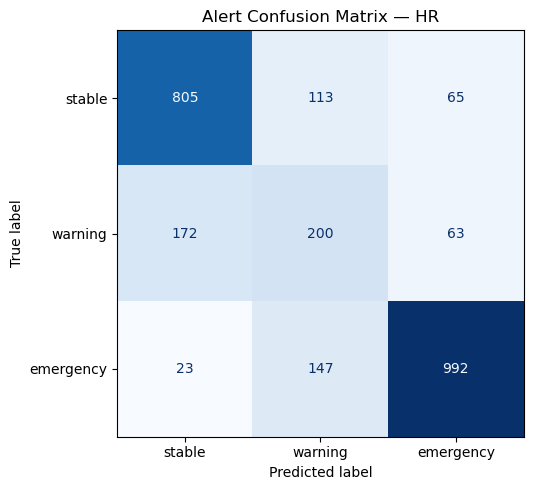

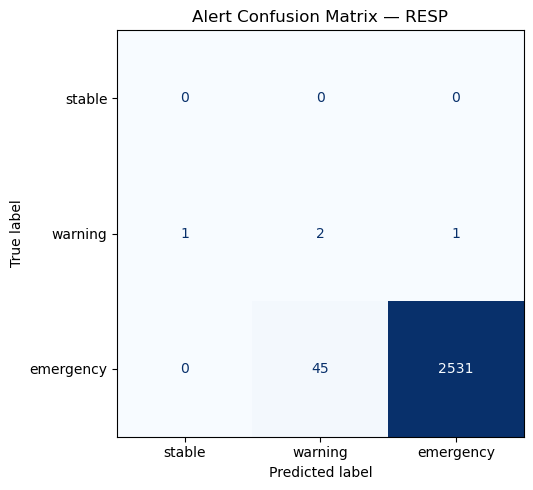

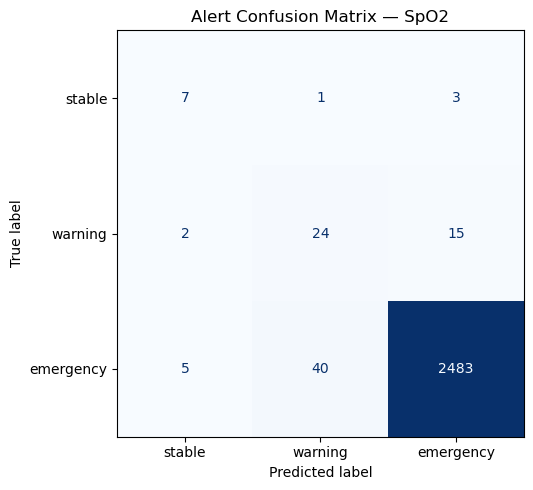

In [59]:
alerts_df = summarize_alert_hitrate(alerts)